# Hybrid Semantic QC Dashboard

This notebook helps you analyze multilingual semantic consistency for both Silver and Gold data.

It reads available CSV/JSON artifacts, summarizes quality flags, and plots similarity distributions.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 140)

In [2]:
BASE = Path.cwd()

PATHS = {
    'silver_cleaned_balanced_csv': BASE / 'artifacts/silver_shard_3_cleaned/silver_shard_3.corrected.cleaned.balanced.csv',
    'silver_hybrid_csv': BASE / 'artifacts/silver_shard_3_qc/silver_shard_3.hybrid.corrected.csv',
    'silver_hybrid_report': BASE / 'artifacts/silver_shard_3_qc/silver_shard_3.hybrid.report.json',
    'silver_cleaned_no_sw_csv': BASE / 'artifacts/silver_shard_3_cleaned_no_sw/silver_shard_3.corrected.cleaned.no_sw.csv',
    'silver_hybrid_no_sw_csv': BASE / 'artifacts/silver_shard_3_qc_no_sw/silver_shard_3.hybrid.noswl.csv',
    'silver_hybrid_no_sw_report': BASE / 'artifacts/silver_shard_3_qc_no_sw/silver_shard_3.hybrid.report.noswl.json',
    'gold_input_merged_csv': BASE / 'artifacts/gold_shard_3_merge/gold_shard_3.corrected.merged.csv',
    'gold_hybrid_csv': BASE / 'artifacts/gold_shard_3_merge/gold_shard_3.hybrid.corrected.csv',
    'gold_hybrid_report': BASE / 'artifacts/gold_shard_3_merge/gold_shard_3.hybrid.report.json',
    'gold_cleaned_no_sw_csv': BASE / 'artifacts/gold_shard_3_cleaned_no_sw/gold_shard_3.corrected.cleaned.no_sw.csv',
    'gold_hybrid_no_sw_csv': BASE / 'artifacts/gold_shard_3_qc_no_sw/gold_shard_3.hybrid.noswl.csv',
    'gold_hybrid_no_sw_report': BASE / 'artifacts/gold_shard_3_qc_no_sw/gold_shard_3.hybrid.report.noswl.json',
}

availability = pd.DataFrame(
    [{'artifact': k, 'exists': v.exists(), 'path': str(v)} for k, v in PATHS.items()]
)
availability

,artifact,exists,path
0,silver_cleaned_balanced_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_cleaned\silver_shard_3.corrected.cleaned.balanced.csv
1,silver_hybrid_csv,False,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_qc\silver_shard_3.hybrid.corrected.csv
2,silver_hybrid_report,False,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_qc\silver_shard_3.hybrid.report.json
3,silver_cleaned_no_sw_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_cleaned_no_sw\silver_shard_3.corrected.cleaned.no_sw.csv
4,silver_hybrid_no_sw_csv,False,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_qc_no_sw\silver_shard_3.hybrid.noswl.csv
5,silver_hybrid_no_sw_report,False,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_qc_no_sw\silver_shard_3.hybrid.report.noswl.json
6,gold_input_merged_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\gold_shard_3_merge\gold_shard_3.corrected.merged.csv
7,gold_hybrid_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\gold_shard_3_merge\gold_shard_3.hybrid.corrected.csv
8,gold_hybrid_report,True,c:\Users\RPC\Desktop\Traduction\artifacts\gold_shard_3_merge\gold_shard_3.hybrid.report.json
9,gold_cleaned_no_sw_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\gold_shard_3_cleaned_no_sw\gold_shard_3.corrected.cleaned.no_sw.csv


In [3]:
def load_csv_safe(path: Path):
    if not path.exists():
        return None
    return pd.read_csv(path, encoding='utf-8-sig', dtype=object)


def load_json_safe(path: Path):
    if not path.exists():
        return None
    with path.open('r', encoding='utf-8') as fp:
        return json.load(fp)

In [4]:
dataframes = {
    'silver_cleaned_balanced': load_csv_safe(PATHS['silver_cleaned_balanced_csv']),
    'silver_hybrid': load_csv_safe(PATHS['silver_hybrid_csv']),
    'silver_cleaned_no_sw': load_csv_safe(PATHS['silver_cleaned_no_sw_csv']),
    'silver_hybrid_no_sw': load_csv_safe(PATHS['silver_hybrid_no_sw_csv']),
    'gold_input_merged': load_csv_safe(PATHS['gold_input_merged_csv']),
    'gold_hybrid': load_csv_safe(PATHS['gold_hybrid_csv']),
    'gold_cleaned_no_sw': load_csv_safe(PATHS['gold_cleaned_no_sw_csv']),
    'gold_hybrid_no_sw': load_csv_safe(PATHS['gold_hybrid_no_sw_csv']),
}

reports = {
    'silver_hybrid_report': load_json_safe(PATHS['silver_hybrid_report']),
    'silver_hybrid_no_sw_report': load_json_safe(PATHS['silver_hybrid_no_sw_report']),
    'gold_hybrid_report': load_json_safe(PATHS['gold_hybrid_report']),
    'gold_hybrid_no_sw_report': load_json_safe(PATHS['gold_hybrid_no_sw_report']),
}

def summarize_df(name, df):
    if df is None:
        return {'dataset': name, 'loaded': False}

    row = {
        'dataset': name,
        'loaded': True,
        'rows': int(len(df)),
        'has_status': 'status' in df.columns,
        'has_consistency_flag': 'consistency_flag' in df.columns,
        'has_similarity_score': 'similarity_score' in df.columns,
    }

    if 'status' in df.columns:
        counts = df['status'].fillna('NA').value_counts().to_dict()
        row['status_counts'] = counts

    if 'consistency_flag' in df.columns:
        counts = df['consistency_flag'].fillna('NA').value_counts().to_dict()
        row['consistency_flag_counts'] = counts

    if 'similarity_score' in df.columns:
        sim = pd.to_numeric(df['similarity_score'], errors='coerce')
        row['avg_similarity'] = float(sim.mean()) if sim.notna().any() else None

    return row

summary_df = pd.DataFrame([summarize_df(name, df) for name, df in dataframes.items()])
summary_df

,dataset,loaded,rows,has_status,has_consistency_flag,has_similarity_score,status_counts,consistency_flag_counts,avg_similarity
0,silver_cleaned_balanced,True,9005.0,True,False,False,"{'CLEAN': 8993, 'FLAGGED': 12}",NaN,NaN
1,silver_hybrid,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,silver_cleaned_no_sw,True,9005.0,True,False,False,"{'CLEAN': 6867, 'FLAGGED': 2134, 'REMOVED': 4}",NaN,NaN
3,silver_hybrid_no_sw,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gold_input_merged,True,1000.0,True,False,False,"{'VALIDATED': 500, 'GENERATED': 373, 'PARTIALLY VALIDATED': 127}",NaN,NaN
5,gold_hybrid,True,1000.0,True,True,True,"{'VALIDATED': 500, 'GENERATED': 373, 'PARTIALLY VALIDATED': 127}","{'CORRECTED': 728, 'CONSISTENT': 270, 'SUSPICIOUS': 2}",0.372708
6,gold_cleaned_no_sw,True,4499.0,True,False,False,"{'CLEAN': 3442, 'FLAGGED': 1055, 'REMOVED': 2}",NaN,NaN
7,gold_hybrid_no_sw,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


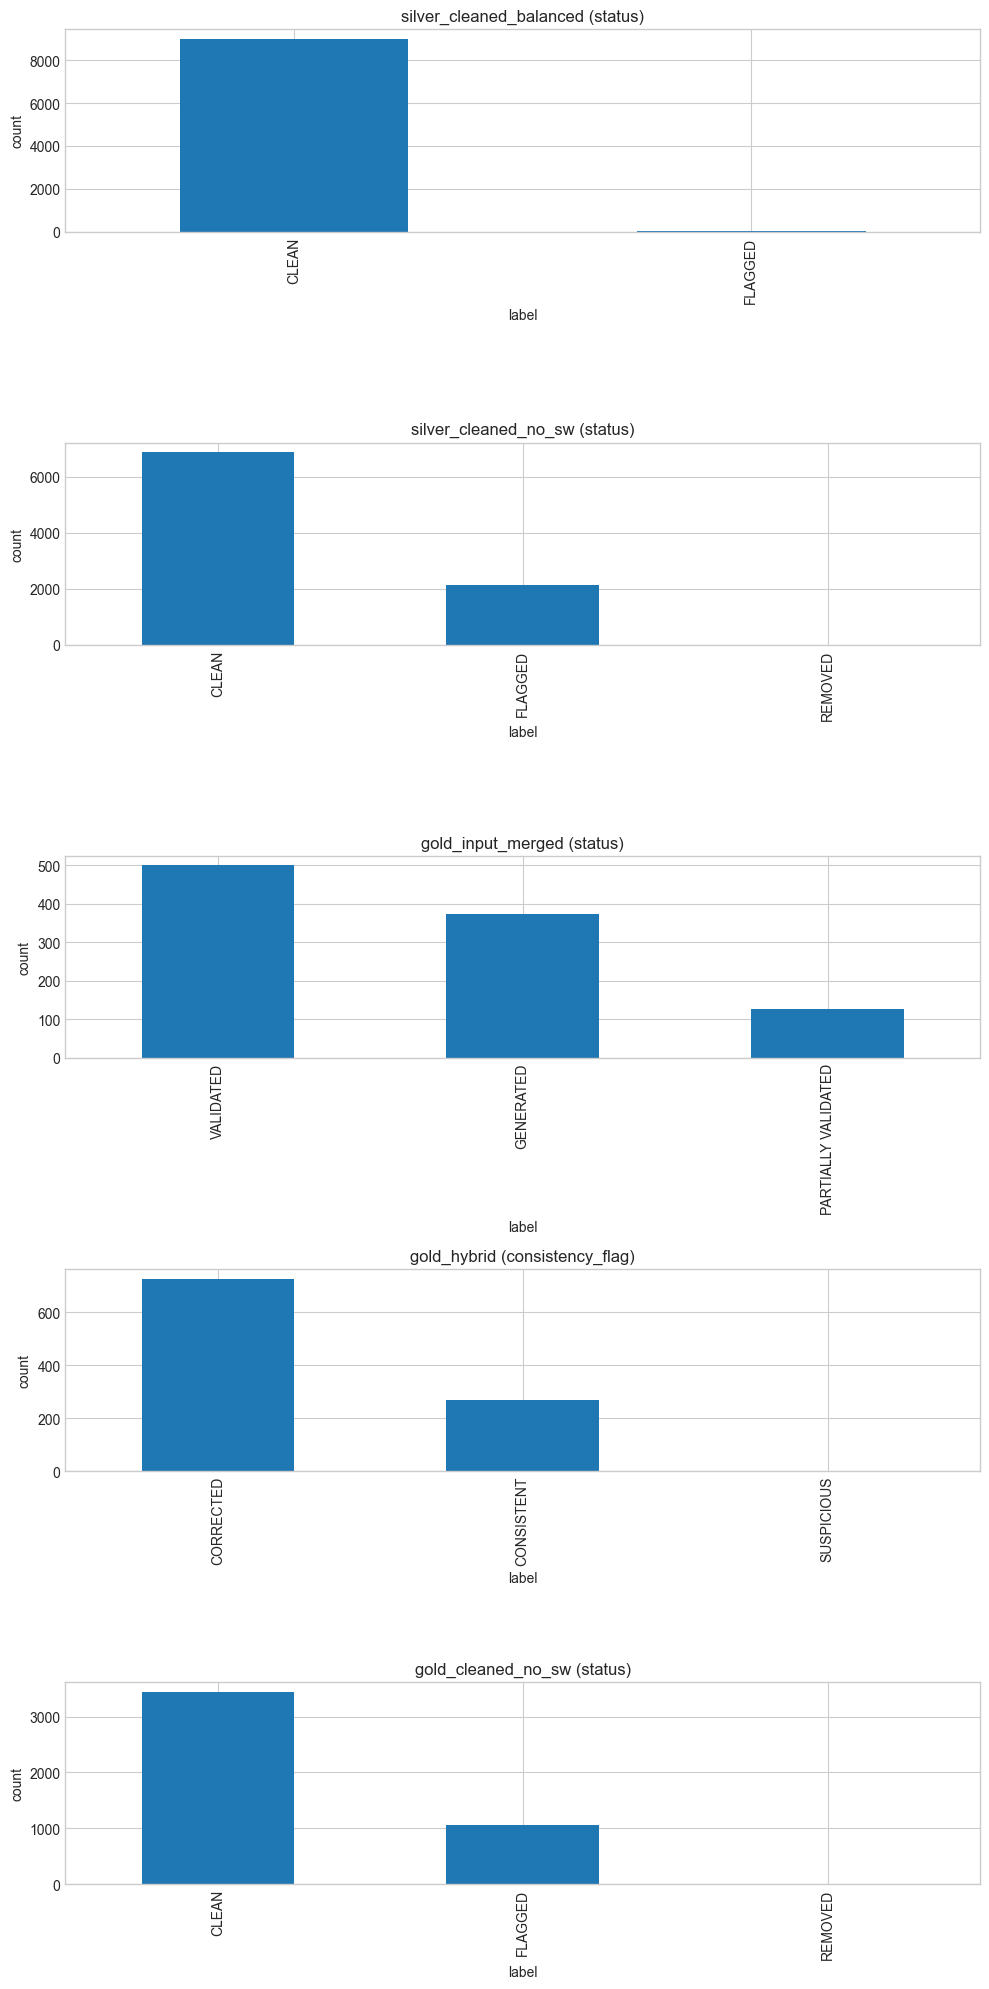

In [5]:
plot_items = []
for name, df in dataframes.items():
    if df is None:
        continue

    if 'consistency_flag' in df.columns:
        counts = df['consistency_flag'].fillna('NA').value_counts()
        plot_items.append((name + ' (consistency_flag)', counts))
    elif 'status' in df.columns:
        counts = df['status'].fillna('NA').value_counts()
        plot_items.append((name + ' (status)', counts))

if plot_items:
    fig, axes = plt.subplots(len(plot_items), 1, figsize=(10, 4 * len(plot_items)))
    if len(plot_items) == 1:
        axes = [axes]

    for ax, (title, counts) in zip(axes, plot_items):
        counts.plot(kind='bar', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('label')
        ax.set_ylabel('count')

    plt.tight_layout()
    plt.show()
else:
    print('No status/consistency columns found to plot.')

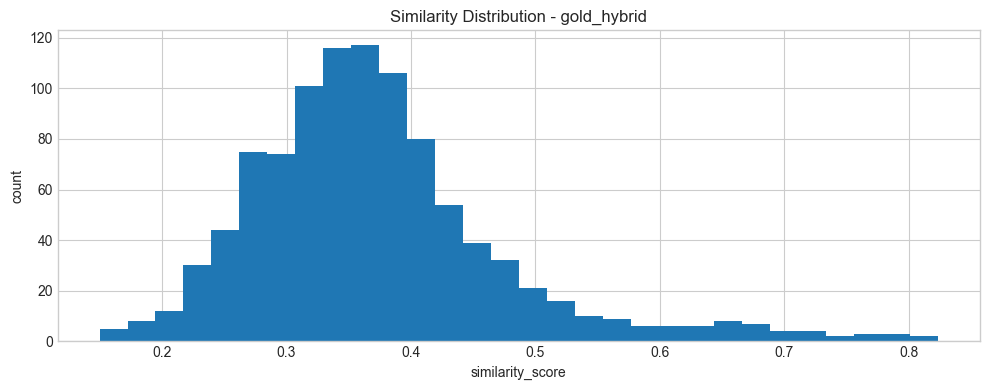

In [6]:
sim_plots = []
for name, df in dataframes.items():
    if df is None or 'similarity_score' not in df.columns:
        continue
    sim = pd.to_numeric(df['similarity_score'], errors='coerce').dropna()
    if not sim.empty:
        sim_plots.append((name, sim))

if sim_plots:
    fig, axes = plt.subplots(len(sim_plots), 1, figsize=(10, 4 * len(sim_plots)))
    if len(sim_plots) == 1:
        axes = [axes]

    for ax, (name, sim) in zip(axes, sim_plots):
        ax.hist(sim.values, bins=30)
        ax.set_title(f'Similarity Distribution - {name}')
        ax.set_xlabel('similarity_score')
        ax.set_ylabel('count')

    plt.tight_layout()
    plt.show()
else:
    print('No similarity_score column found yet. Run hybrid_semantic_consistency.py first.')

In [7]:
report_rows = []
wanted_keys = [
    'total_rows',
    'consistent_rows',
    'suspicious_rows',
    'corrected_rows',
    'average_similarity',
    'llm_calls',
    'estimated_cost_usd',
]

for report_name, report_data in reports.items():
    if report_data is None:
        report_rows.append({'report': report_name, 'loaded': False})
        continue

    row = {'report': report_name, 'loaded': True}
    for key in wanted_keys:
        row[key] = report_data.get(key)
    report_rows.append(row)

pd.DataFrame(report_rows)

,report,loaded,total_rows,consistent_rows,suspicious_rows,corrected_rows,average_similarity,llm_calls,estimated_cost_usd
0,silver_hybrid_report,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,silver_hybrid_no_sw_report,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gold_hybrid_report,True,1000.0,270.0,2.0,728.0,0.372708,998.0,0.657708
3,gold_hybrid_no_sw_report,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


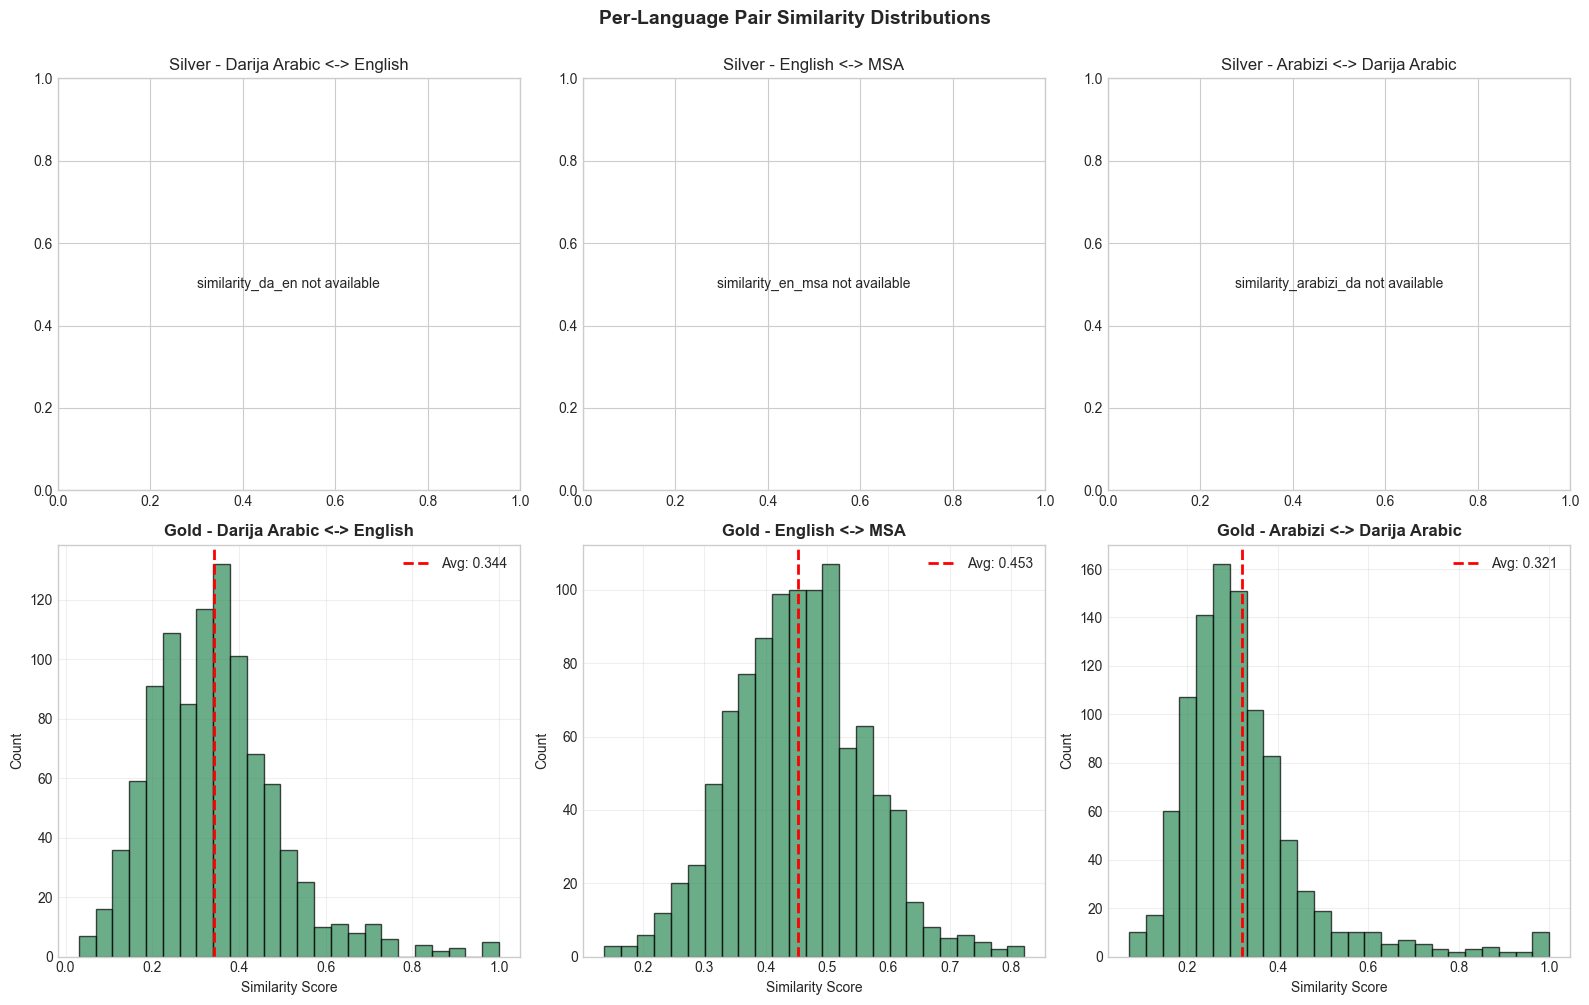


=== Per-Language Pair Statistics ===



,Dataset,Language Pair,Count,Mean,Median,Std Dev,Min,Max
0,Gold,Darija Arabic <-> English,1000,0.3436,0.3315,0.1476,0.0303,1.0000
1,Gold,English <-> MSA,1000,0.4533,0.4518,0.1069,0.1361,0.8214
2,Gold,Arabizi <-> Darija Arabic,1000,0.3212,0.2952,0.1436,0.0706,1.0000


In [8]:
import numpy as np
import seaborn as sns

# Per-language similarity breakdown
language_pairs = [
    ('similarity_da_en', 'Darija Arabic <-> English'),
    ('similarity_en_msa', 'English <-> MSA'),
    ('similarity_arabizi_da', 'Arabizi <-> Darija Arabic'),
]

silver_hybrid = dataframes.get('silver_hybrid')
gold_hybrid = dataframes.get('gold_hybrid')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, (col, label) in enumerate(language_pairs):
    ax_silver = axes[0, idx]
    ax_gold = axes[1, idx]
    
    # Silver
    if silver_hybrid is not None and col in silver_hybrid.columns:
        sim_s = pd.to_numeric(silver_hybrid[col], errors='coerce').dropna()
        ax_silver.hist(sim_s.values, bins=25, alpha=0.7, color='steelblue', edgecolor='black')
        ax_silver.axvline(sim_s.mean(), color='red', linestyle='--', linewidth=2, label=f'Avg: {sim_s.mean():.3f}')
        ax_silver.set_title(f'Silver - {label}', fontsize=12, fontweight='bold')
        ax_silver.set_xlabel('Similarity Score')
        ax_silver.set_ylabel('Count')
        ax_silver.legend()
        ax_silver.grid(True, alpha=0.3)
    else:
        ax_silver.text(0.5, 0.5, f'{col} not available', ha='center', va='center', transform=ax_silver.transAxes)
        ax_silver.set_title(f'Silver - {label}')
    
    # Gold
    if gold_hybrid is not None and col in gold_hybrid.columns:
        sim_g = pd.to_numeric(gold_hybrid[col], errors='coerce').dropna()
        ax_gold.hist(sim_g.values, bins=25, alpha=0.7, color='seagreen', edgecolor='black')
        ax_gold.axvline(sim_g.mean(), color='red', linestyle='--', linewidth=2, label=f'Avg: {sim_g.mean():.3f}')
        ax_gold.set_title(f'Gold - {label}', fontsize=12, fontweight='bold')
        ax_gold.set_xlabel('Similarity Score')
        ax_gold.set_ylabel('Count')
        ax_gold.legend()
        ax_gold.grid(True, alpha=0.3)
    else:
        ax_gold.text(0.5, 0.5, f'{col} not available', ha='center', va='center', transform=ax_gold.transAxes)
        ax_gold.set_title(f'Gold - {label}')

plt.suptitle('Per-Language Pair Similarity Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Statistics table
print("\n=== Per-Language Pair Statistics ===\n")
stats_rows = []
for col, label in language_pairs:
    for dataset_name, df in [('Silver', silver_hybrid), ('Gold', gold_hybrid)]:
        if df is not None and col in df.columns:
            sim = pd.to_numeric(df[col], errors='coerce').dropna()
            stats_rows.append({
                'Dataset': dataset_name,
                'Language Pair': label,
                'Count': len(sim),
                'Mean': round(sim.mean(), 4),
                'Median': round(sim.median(), 4),
                'Std Dev': round(sim.std(), 4),
                'Min': round(sim.min(), 4),
                'Max': round(sim.max(), 4),
            })

pd.DataFrame(stats_rows)

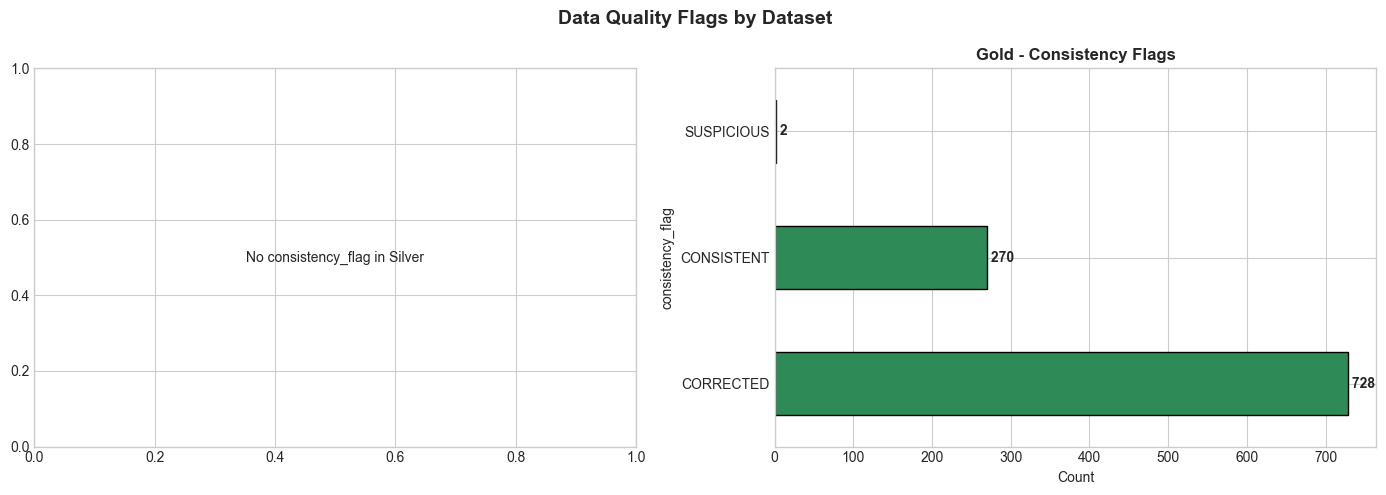


=== Consistency Flag Breakdown ===



,Dataset,Flag,Count,Percentage
0,Gold,CORRECTED,728,72.8%
1,Gold,CONSISTENT,270,27.0%
2,Gold,SUSPICIOUS,2,0.2%


In [9]:
# Consistency flag breakdown by dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silver
if silver_hybrid is not None and 'consistency_flag' in silver_hybrid.columns:
    flag_counts = silver_hybrid['consistency_flag'].fillna('UNKNOWN').value_counts()
    flag_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Silver - Consistency Flags', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Count')
    for i, v in enumerate(flag_counts.values):
        axes[0].text(v, i, f' {v}', va='center', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No consistency_flag in Silver', ha='center', va='center', transform=axes[0].transAxes)

# Gold
if gold_hybrid is not None and 'consistency_flag' in gold_hybrid.columns:
    flag_counts = gold_hybrid['consistency_flag'].fillna('UNKNOWN').value_counts()
    flag_counts.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
    axes[1].set_title('Gold - Consistency Flags', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Count')
    for i, v in enumerate(flag_counts.values):
        axes[1].text(v, i, f' {v}', va='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No consistency_flag in Gold', ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Data Quality Flags by Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Consistency Flag Breakdown ===\n")
flag_rows = []
for dataset_name, df in [('Silver', silver_hybrid), ('Gold', gold_hybrid)]:
    if df is not None and 'consistency_flag' in df.columns:
        flags = df['consistency_flag'].fillna('UNKNOWN').value_counts()
        total = len(df)
        for flag, count in flags.items():
            flag_rows.append({
                'Dataset': dataset_name,
                'Flag': flag,
                'Count': count,
                'Percentage': f'{100*count/total:.1f}%',
            })

pd.DataFrame(flag_rows)

In [10]:
# Low similarity warnings and patterns
print("\n=== Low Similarity Analysis (score < 0.50) ===\n")

low_sim_rows = []
for dataset_name, df in [('Silver', silver_hybrid), ('Gold', gold_hybrid)]:
    if df is None:
        continue
    
    # Check overall similarity score
    if 'similarity_score' in df.columns:
        sim_overall = pd.to_numeric(df['similarity_score'], errors='coerce')
        low_overall = (sim_overall < 0.50).sum()
        low_sim_rows.append({
            'Dataset': dataset_name,
            'Metric': 'Overall Score < 0.50',
            'Count': low_overall,
            'Percentage': f'{100*low_overall/len(df):.1f}%'
        })
    
    # Check per-language pair
    for col, label in language_pairs:
        if col in df.columns:
            sim = pd.to_numeric(df[col], errors='coerce')
            low_count = (sim < 0.50).sum()
            low_sim_rows.append({
                'Dataset': dataset_name,
                'Metric': f'{label} < 0.50',
                'Count': low_count,
                'Percentage': f'{100*low_count/len(df):.1f}%'
            })

pd.DataFrame(low_sim_rows)

# Relationship between similarity score and consistency flag
if silver_hybrid is not None and 'similarity_score' in silver_hybrid.columns and 'consistency_flag' in silver_hybrid.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Silver
    sim_s = pd.to_numeric(silver_hybrid['similarity_score'], errors='coerce')
    flag_s = silver_hybrid['consistency_flag'].fillna('UNKNOWN')
    
    for flag in flag_s.unique():
        mask = (flag_s == flag)
        scores = sim_s[mask].dropna()
        axes[0].hist(scores.values, bins=20, alpha=0.6, label=flag, edgecolor='black')
    
    axes[0].set_title('Silver - Similarity Distribution by Consistency Flag', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Overall Similarity Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Gold
    if gold_hybrid is not None and 'similarity_score' in gold_hybrid.columns and 'consistency_flag' in gold_hybrid.columns:
        sim_g = pd.to_numeric(gold_hybrid['similarity_score'], errors='coerce')
        flag_g = gold_hybrid['consistency_flag'].fillna('UNKNOWN')
        
        for flag in flag_g.unique():
            mask = (flag_g == flag)
            scores = sim_g[mask].dropna()
            axes[1].hist(scores.values, bins=20, alpha=0.6, label=flag, edgecolor='black')
        
        axes[1].set_title('Gold - Similarity Distribution by Consistency Flag', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Overall Similarity Score')
        axes[1].set_ylabel('Count')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Similarity Score vs Consistency Flag Relationship', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


=== Low Similarity Analysis (score < 0.50) ===



In [11]:
# Comparative analysis: Silver vs Gold
print("\n=== Silver vs Gold Comparative Analysis ===\n")

comparison_rows = []
metrics = {
    'Total Rows': lambda df: len(df),
    'Avg Overall Similarity': lambda df: round(pd.to_numeric(df.get('similarity_score', []), errors='coerce').mean(), 4) if 'similarity_score' in df.columns else None,
    'Median Overall Similarity': lambda df: round(pd.to_numeric(df.get('similarity_score', []), errors='coerce').median(), 4) if 'similarity_score' in df.columns else None,
    'Rows with Consistency Flag': lambda df: (df.get('consistency_flag', pd.Series([])).notna()).sum() if 'consistency_flag' in df.columns else None,
}

for dataset_name, df in [('Silver', silver_hybrid), ('Gold', gold_hybrid)]:
    if df is None:
        continue
    for metric_name, metric_func in metrics.items():
        value = metric_func(df)
        comparison_rows.append({
            'Dataset': dataset_name,
            'Metric': metric_name,
            'Value': value
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df_pivot = comparison_df.pivot(index='Metric', columns='Dataset', values='Value')
print(comparison_df_pivot)
print()

# Side-by-side similarity score distribution
if silver_hybrid is not None and gold_hybrid is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    if 'similarity_score' in silver_hybrid.columns:
        sim_s = pd.to_numeric(silver_hybrid['similarity_score'], errors='coerce').dropna()
        axes[0].hist(sim_s.values, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[0].axvline(sim_s.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sim_s.mean():.3f}')
        axes[0].set_title(f'Silver Overall Similarity (n={len(sim_s)})', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Similarity Score')
        axes[0].set_ylabel('Count')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    if 'similarity_score' in gold_hybrid.columns:
        sim_g = pd.to_numeric(gold_hybrid['similarity_score'], errors='coerce').dropna()
        axes[1].hist(sim_g.values, bins=30, alpha=0.7, color='seagreen', edgecolor='black')
        axes[1].axvline(sim_g.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sim_g.mean():.3f}')
        axes[1].set_title(f'Gold Overall Similarity (n={len(sim_g)})', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Similarity Score')
        axes[1].set_ylabel('Count')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Silver vs Gold: Overall Similarity Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Summary statistics comparison
print("\n=== Dataset Quality Summary ===\n")
summary_rows = []

for dataset_name, df in [('Silver', silver_hybrid), ('Gold', gold_hybrid)]:
    if df is None:
        continue
    
    # Basic stats
    summary_rows.append({
        'Dataset': dataset_name,
        'Property': 'Total Rows',
        'Value': len(df),
        'Unit': 'rows'
    })
    
    # Consistency flags
    if 'consistency_flag' in df.columns:
        consistent = (df['consistency_flag'] == 'CONSISTENT').sum()
        suspicious = (df['consistency_flag'] == 'SUSPICIOUS').sum()
        summary_rows.append({
            'Dataset': dataset_name,
            'Property': 'Consistent Rows',
            'Value': f"{consistent} ({100*consistent/len(df):.1f}%)",
            'Unit': ''
        })
        summary_rows.append({
            'Dataset': dataset_name,
            'Property': 'Suspicious Rows',
            'Value': f"{suspicious} ({100*suspicious/len(df):.1f}%)",
            'Unit': ''
        })
    
    # Similarity metrics
    if 'similarity_score' in df.columns:
        sim = pd.to_numeric(df['similarity_score'], errors='coerce').dropna()
        summary_rows.append({
            'Dataset': dataset_name,
            'Property': 'Avg Similarity',
            'Value': f"{sim.mean():.4f}",
            'Unit': '0-1 scale'
        })

pd.DataFrame(summary_rows)


=== Silver vs Gold Comparative Analysis ===

Dataset                          Gold
Metric                               
Avg Overall Similarity         0.3727
Median Overall Similarity      0.3578
Rows with Consistency Flag  1000.0000
Total Rows                  1000.0000


=== Dataset Quality Summary ===



,Dataset,Property,Value,Unit
0,Gold,Total Rows,1000,rows
1,Gold,Consistent Rows,270 (27.0%),
2,Gold,Suspicious Rows,2 (0.2%),
3,Gold,Avg Similarity,0.3727,0-1 scale



=== Word Count Analysis by Language ===

Dataset               Language                 Column  Avg Words  Median Words  Min Words  Max Words  Std Dev
   Gold          Darija Arabic          darija_arabic      21.67            22          2         90    12.10
   Gold                Arabizi         darija_arabizi      22.87            23          2         90    12.99
   Gold                English                english      23.87            24          5         69    12.14
   Gold Modern Standard Arabic modern_standard_arabic      21.03            21          2         80    11.60


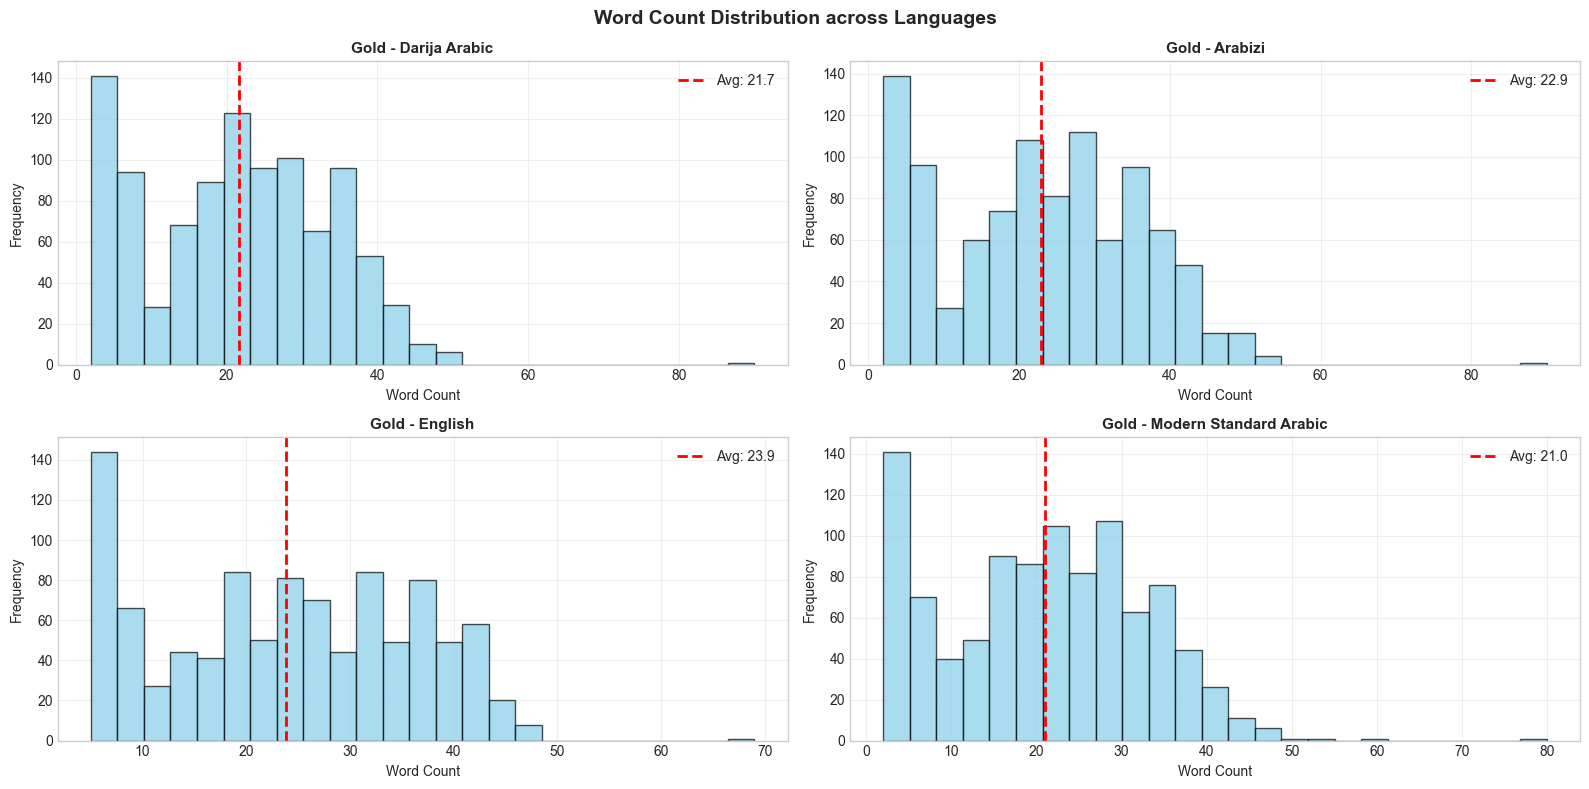

In [12]:
# Word count analysis by language
print("\n=== Word Count Analysis by Language ===\n")

language_columns = {
    'darija_arabic': 'Darija Arabic',
    'darija_arabizi': 'Arabizi',
    'english': 'English',
    'modern_standard_arabic': 'Modern Standard Arabic',
}

def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

word_count_rows = []
for dataset_name, df in [('Silver', silver_hybrid), ('Gold', gold_hybrid)]:
    if df is None:
        continue
    
    for col, label in language_columns.items():
        if col in df.columns:
            word_counts = df[col].apply(count_words)
            word_count_rows.append({
                'Dataset': dataset_name,
                'Language': label,
                'Column': col,
                'Avg Words': round(word_counts.mean(), 2),
                'Median Words': int(word_counts.median()),
                'Min Words': int(word_counts.min()),
                'Max Words': int(word_counts.max()),
                'Std Dev': round(word_counts.std(), 2),
            })

wc_df = pd.DataFrame(word_count_rows)
print(wc_df.to_string(index=False))

# Visualize word count distributions
if silver_hybrid is not None or gold_hybrid is not None:
    datasets_with_cols = []
    for dataset_name, df in [('Silver', silver_hybrid), ('Gold', gold_hybrid)]:
        if df is not None:
            for col, label in language_columns.items():
                if col in df.columns:
                    datasets_with_cols.append((dataset_name, label, col, df))
    
    if datasets_with_cols:
        n_plots = len(datasets_with_cols)
        fig, axes = plt.subplots((n_plots + 1) // 2, 2, figsize=(16, 4 * ((n_plots + 1) // 2)))
        axes = axes.flatten()
        
        for idx, (dataset_name, label, col, df) in enumerate(datasets_with_cols):
            word_counts = df[col].apply(count_words)
            axes[idx].hist(word_counts.values, bins=25, alpha=0.7, color='skyblue', edgecolor='black')
            axes[idx].axvline(word_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Avg: {word_counts.mean():.1f}')
            axes[idx].set_title(f'{dataset_name} - {label}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Word Count')
            axes[idx].set_ylabel('Frequency')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)
        
        # Hide extra subplots
        for idx in range(len(datasets_with_cols), len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle('Word Count Distribution across Languages', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## Run Hybrid QC for Silver and Gold

Before running, set OPENAI_API_KEY in your shell.

Example commands:

```bash
py -3 hybrid_semantic_consistency.py --input artifacts/silver_shard_3_cleaned/silver_shard_3.corrected.cleaned.balanced.csv --output artifacts/silver_shard_3_qc/silver_shard_3.hybrid.corrected.csv --report artifacts/silver_shard_3_qc/silver_shard_3.hybrid.report.json --threshold 0.80 --model gpt-4.1-mini --workers 6

py -3 hybrid_semantic_consistency.py --input artifacts/gold_shard_3_merge/gold_shard_3.corrected.merged.csv --output artifacts/gold_shard_3_merge/gold_shard_3.hybrid.corrected.csv --report artifacts/gold_shard_3_merge/gold_shard_3.hybrid.report.json --threshold 0.80 --model gpt-4.1-mini --workers 6
```